# Least Absolute Shrinkage and Selection Operator (LASSO); Subgradient descent, Projected gradient descent and Proximal gradient descent 

References:

https://stanford.edu/class/ee364b/lectures/subgradients_notes.pdf
https://hastie.su.domains/StatLearnSparsity/
https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture7.pdf
https://ai.stanford.edu/~jduchi/projects/jd_ss_ys_l1.pdf

## The LASSO problem

Let $\mathbf{X} \in \mathbb{R}^{N \times p}$, $\mathbf{y} \in \mathbb{R}^{N}$, being $p$ the number of "features" and $N$ the number of "observations". The LASSO problem is:
$$\begin{aligned}
\min_{\beta \in \mathbb{R}^p} \quad & \frac{1}{2N} \|\mathbf{y} - \mathbf{X}\beta\|_2^2 \\
\text{subject to} \quad & \|\beta\|_1 \leq t
\end{aligned}$$

Which, as long as the constrain is active we have a one-to-one correspondence with a Lagrangian formulation in terms of $\lambda$:

$$\min_{\beta \in \mathbb{R}^p} \left\{ \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\beta\|_2^2 + \lambda \|\beta\|_1 \right\}$$

In [11]:
# generate some data form a 100 dimensions 1000 observations LASSO problem
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
from scipy.optimize import minimize

np.random.seed(0)
n_samples, n_features = 50, 100
X = np.random.randn(n_samples, n_features)
coef = 3 * np.random.randn(n_features)
coef[10:] = 0  # only the top 10 features are relevant
y = X @ coef + np.random.normal(scale=1, size=n_samples)
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Subgradient descent

Let us consider the absolute value function $|x|$. Applying the definition of the derivative at $x = 0$, we find that:

$$\lim_{h \to 0^+} \frac{|0 + h| - |0|}{h} = 1 \neq  \lim_{h \to 0^-} \frac{|0 + h| - |0|}{h} = -1.$$

Hence, the function is not differentiable.

A workaround (which easily holds for convex functions) is the subgradient:

A vector $g \in \mathbb{R}^n$ is a subgradient of $f:\mathbb{R}^n \rightarrow \mathbb{R}$ at $x \in \text{dom}\, f$ (refered to as $\partial f(x)$) if 
$$f(z) \geq f(x) + g^{\top}(z - x)$$
$\forall z \in \text{dom} \,f$

For $|x|$ is actually very simple:

$$\partial |x| = 
\begin{cases} 
\{1\} & \text{if } x > 0 \\ 
\{-1\} & \text{if } x < 0 \\ 
[-1, 1] & \text{if } x = 0 
\end{cases}$$




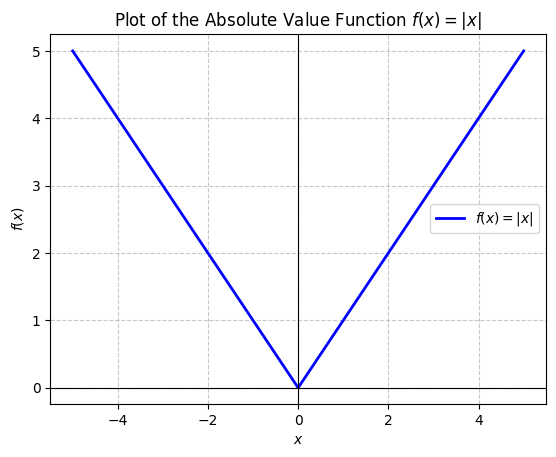

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
x = np.linspace(-5, 5, 400)
y = np.abs(x)

# Plotting
plt.plot(x, y, label='$f(x) = |x|$', color='blue', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Plot of the Absolute Value Function $f(x) = |x|$')
plt.legend()
plt.show()

Now, from the definition of subgradient we have that:

$$ 0 \in \partial f(x) \implies f(y) \geq f(x) \, \forall y \in \text{dom} \, f.$$

And hence that is a condition for optimality.

This allow to proceed with a (sub)gradient descent approach! However, the convergence rate of this algorithm is $\mathcal{O}(\frac{1}{\sqrt{k} })$ for $k$ being the number of iterations. 

Looking at the lasso problem, taking the derivative:

$$\frac{\partial \big (\frac{1}{2n} \|\mathbf{y} - \mathbf{X}\beta\|_2^2 + \lambda \|\beta\|_1 \big )}{\partial \beta} = -\mathbf{X}^{\top}\mathbf{y} + \mathbf{X}^{\top}\mathbf{X}\beta +  \lambda \partial \|\beta\|_1$$



In [13]:
def subgradient_method(X, y, X_test, y_test, coef, lam=1.0, t0=1.0, max_iter=500, tol=1e-16):
    """
    Subgradient method for LASSO with diminishing step size.
    Minimizes f(w) = (1/(2n))||y - Xw||^2 + lam * ||w||_1
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    
    # Trackers for the best point found (since f(w) may increase)
    w_best = np.copy(w)
    
    def obj(w_val):
        res = y - X @ w_val
        return 0.5 * np.dot(res, res) / n_samples + lam * np.sum(np.abs(w_val))
    
    def obj_test(w_val):
        res = y_test - X_test @ w_val
        return 0.5 * np.dot(res, res) / n_samples
    
    f_best = obj(w)
    losses = [obj_test(w)]
    distance_to_true = [np.linalg.norm(w - coef)]

    for k in range(1, max_iter + 1):
        # 1. Compute subgradient
        # grad_smooth = (1/n) * X^T * (Xw - y)
        grad_smooth = (X.T @ (X @ w - y)) / n_samples
        sub_l1 = np.sign(w) # sign(0) is 0 in numpy
        subgrad = grad_smooth + lam * sub_l1

        # 2. Check convergence
        if np.linalg.norm(subgrad) < tol:
            break

        # 3. Diminishing step size rule: t_k = t0 / k
        t_k = t0 /np.sqrt(k)

        # 4. Update (Standard Step)
        w = w - t_k * subgrad
        
        # 5. Keep track of the best result (crucial for non-descent methods)
        current_f = obj(w)
        if current_f < f_best:
            f_best = current_f
            w_best = np.copy(w)

        # Log metrics (using test data as requested)
        losses.append(obj_test(w))
        distance_to_true.append(np.linalg.norm(w - coef))

    return w_best, losses, distance_to_true


def plot_loss_curves(loss_dict, distances_dict, logy=True):
    """
    Plot loss curves for multiple algorithms.
    loss_dict: dictionary where keys are algorithm names and values are lists of losses
    distances_dict: dictionary where keys are algorithm names and values are lists of distances to true coefficients
    logy: whether to use logarithmic scale for y-axis
    """
    plt.figure(figsize=(12, 5))
    
    # Plot losses
    plt.subplot(1, 2, 1)
    for alg_name, losses in loss_dict.items():
        plt.plot(losses, label=alg_name)
    plt.xlabel('Iteration')
    plt.ylabel('Test Loss')
    if logy:
        plt.yscale('log')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot distances to true coefficients
    plt.subplot(1, 2, 2)
    for alg_name, distances in distances_dict.items():
        plt.plot(distances, label=alg_name)
    plt.xlabel('Iteration')
    plt.ylabel('Distance to True Coefficients')
    if logy:
        plt.yscale('log')
    plt.title('Distance to True Coefficients')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

def plot_coefficients(w_est, w_true):
    plt.figure(figsize=(10, 6))
    plt.plot(w_true, label='True Coefficients', marker='o')
    plt.plot(w_est, label='Estimated Coefficients', marker='x')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Coefficient Index')
    plt.ylabel('Coefficient Value')
    plt.title('True vs Estimated Coefficients')
    plt.legend()
    plt.show()


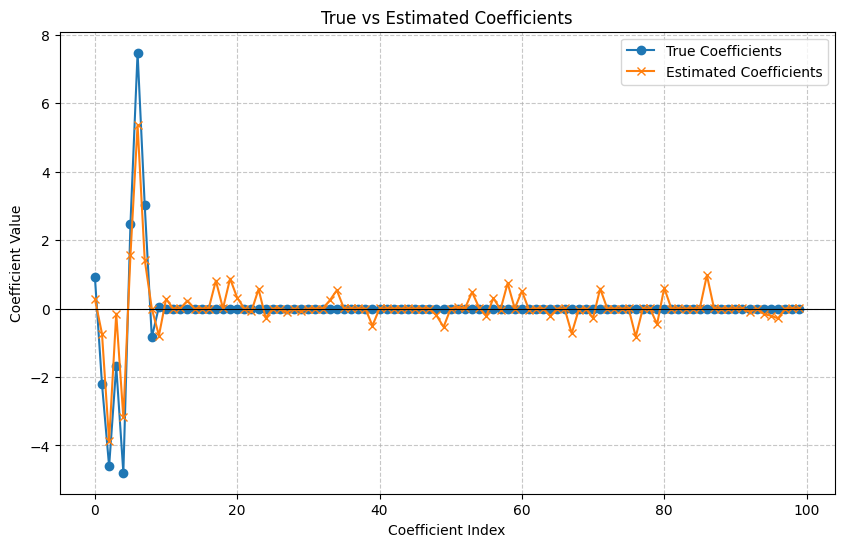

Time taken (seconds): 0.014673233032226562
Number of exact zeros in estimated coefficients: 0


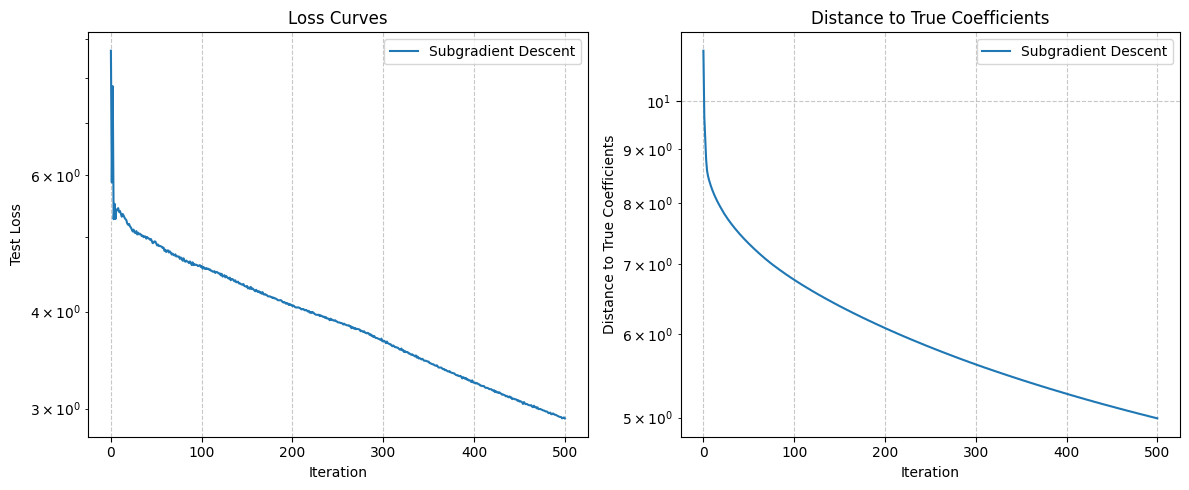

In [14]:
# Run the subgradient descent
start_time = time.time()
w_est, losses, distance_to_true = subgradient_method(X_train, y_train, X_test, y_test, coef, lam=0.1, t0 = 0.5, max_iter=500)
time_taken = time.time() - start_time
plot_coefficients(w_est, coef)
print("Time taken (seconds):", time_taken)
# number of exact zeros in the estimated coefficients
print("Number of exact zeros in estimated coefficients:", np.sum(w_est == 0))
plot_loss_curves({'Subgradient Descent': losses}, {'Subgradient Descent': distance_to_true}, logy=True)

It works kind of alright, the main issue is that it does not generate 0s! This is what one would get when doing naive lasso regression using torch automatic differentiation over the absolute value and forgetting about it.

Are there any other issues with this?

### Projected gradient descent

We are back at the constrained optimization problem formulation. The idea is to keep $\beta$ inside of the set described by the constraint $\|\beta\|_1 \leq t$. This is, while the gradient step might get out of the set, we will push it back to it. In particular, we will find the element in the set that is closest to our current value in terms of euclidean distance.

The projection operator $P_C$ is defined as:

$$P_C(x) \coloneqq \arg\min_{z \in C} \frac{1}{2} \|z - x\|_2^2,$$

where $C = \{\beta :\|\beta\|_1 \leq t\}$.

Somewhat suprisingly, the convergence rate of projected gradient descent is the same as gradient descent: $\mathcal{O}(\frac{1}{k})$

The problem, however, is that calculating the projection into the L1 ball is not trivial. Nevertheless, efficient algorithms exists, the following is $\mathcal{O}(n \log{n})$.

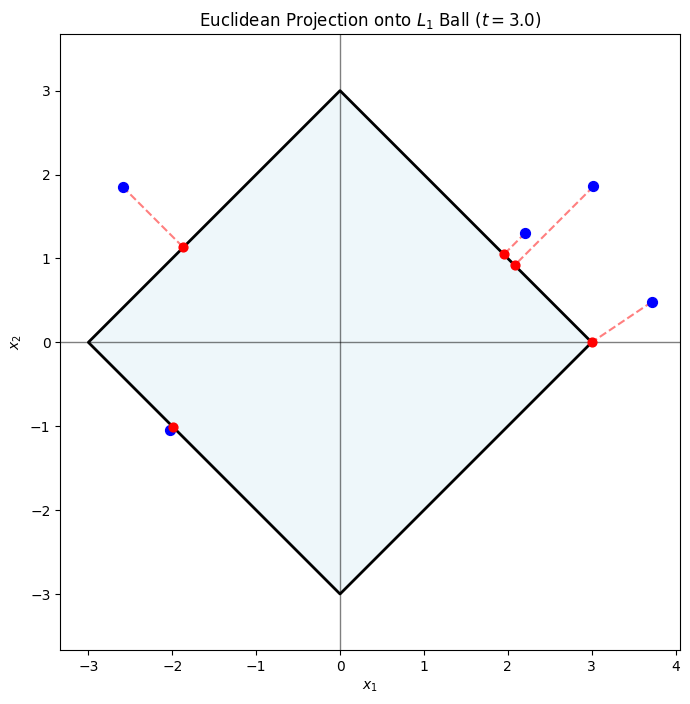

In [15]:
def project_l1_ball(v, t):
    """
    Compute the Euclidean projection of a vector v onto the L1 ball of radius t.
    """
    abs_v = np.abs(v)
    if np.sum(abs_v) <= t:
        return v # Already inside
    # this is algo from figure 1 in https://ai.stanford.edu/~jduchi/projects/jd_ss_ys_l1.pdf
    # Projection onto the simplex of absolute values
    u = np.sort(abs_v)[::-1]
    cssv = np.cumsum(u)
    indices = np.arange(1, len(v) + 1)
    cond = u - (cssv - t) / indices > 0
    rho = indices[cond][-1] # like np.max(np.where(cond))
    theta = (cssv[rho-1] - t) / rho
    
    w = np.sign(v) * np.maximum(abs_v - theta, 0)
    return w

# Parameters
t = 3.0  
np.random.seed(422)
num_points = 5
points = np.random.uniform(-4, 4, (num_points, 2))

# Calculate projections
projections = np.array([project_l1_ball(p, t) for p in points])

# Create the plot
plt.figure(figsize=(8, 8))

# Draw the L1 ball (diamond shape)
ball_x = [t, 0, -t, 0, t]
ball_y = [0, t, 0, -t, 0]
plt.plot(ball_x, ball_y, 'k-', linewidth=2, label=f'$L_1$ ball ($t={t}$)')
plt.fill(ball_x, ball_y, color='lightblue', alpha=0.2)

# Plot points and their projection paths
for i in range(num_points):
    p, proj = points[i], projections[i]
    plt.plot([p[0], proj[0]], [p[1], proj[1]], 'r--', alpha=0.5)
    plt.scatter(p[0], p[1], color='blue', s=50, zorder=5)
    plt.scatter(proj[0], proj[1], color='red', s=40, zorder=6)

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)
plt.axis('equal')
plt.title(f'Euclidean Projection onto $L_1$ Ball ($t={t}$)')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.savefig('l1_projection.png')

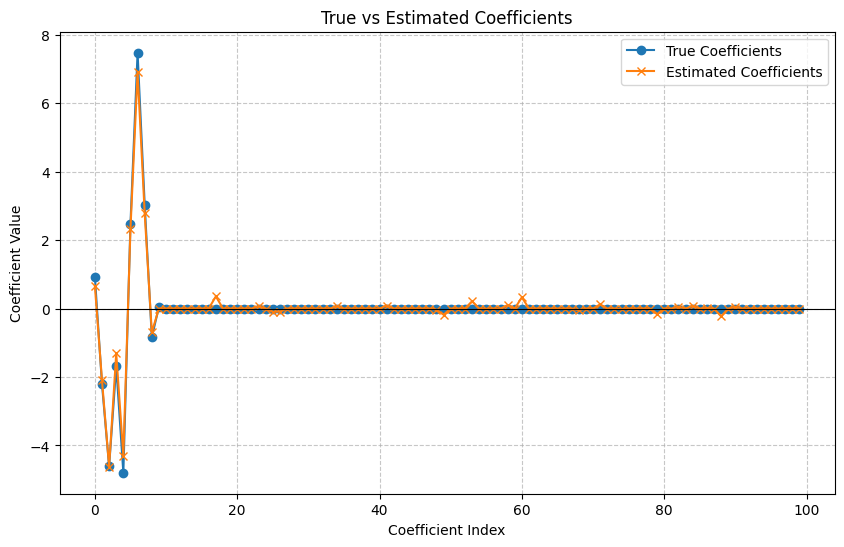

Time taken (seconds): 0.017258644104003906
Number of exact zeros in estimated coefficients: 70


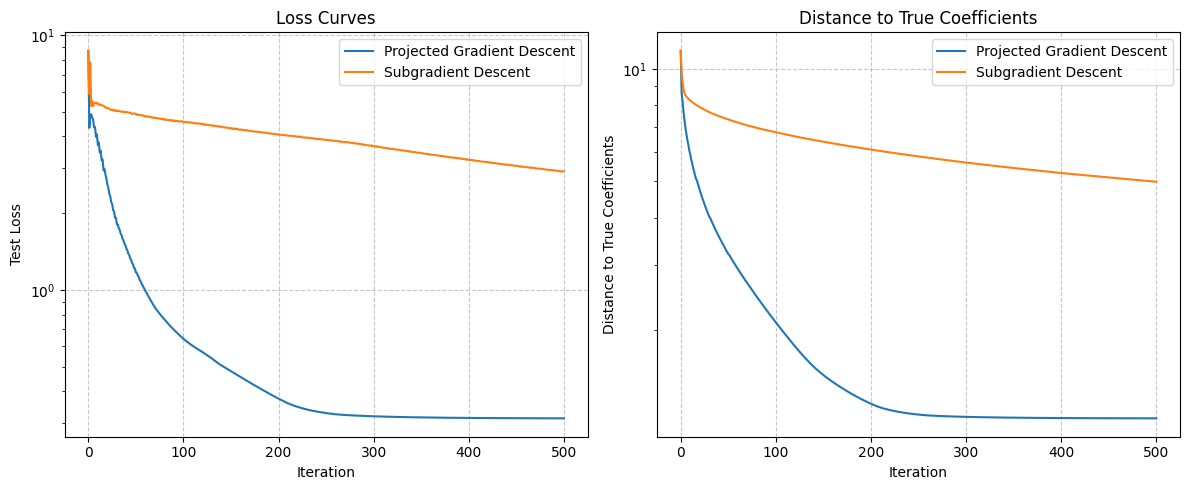

In [16]:
def projected_gradient_descent(X, y, X_test, y_test, coef, lam, t0=1.0, beta=0.5, c=1e-4, max_iter=500, tol=1e-16):
    """
    Projected gradient descent for LASSO.
    Minimizes (1/(2n))||y - Xw||^2 subject to ||w||_1 <= t (where t = lam)

    Returns:
    - w: estimated coefficients
    - losses: list with objective value at initialization and after each update
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)

    def obj(w):
        res = y - X @ w
        return 0.5 * np.dot(res, res) / n_samples
    
    def obj_test(w):
        res = y_test - X_test @ w
        return 0.5 * np.dot(res, res) / n_samples
    
    losses = []
    distance_from_coef = []
    losses.append(obj_test(w))
    distance_from_coef.append(np.linalg.norm(w - coef))

    for _ in range(max_iter):
        # gradient of the smooth part (1/(2n)||y-Xw||^2)
        grad = - (X.T @ (y - X @ w)) / n_samples
        if np.linalg.norm(grad) < tol:
            break
        # backtracking line search
        t = t0
        f_w = obj(w)
        # Armijo-like condition for subgradient: f(w - t g) <= f(w) - c * t * ||g||^2
        while t > 1e-20:
            w_new = w - t * grad
            f_new = obj(w_new)
            if f_new <= f_w - c * t * np.dot(grad, grad):
                break
            t *= beta
        if t <= 1e-20:
            break
        # take a gradient step
        w_tmp = w - t * grad
        #print(w_temp)
        # project back onto the L1 ball of radius lam
        w_new = project_l1_ball(w_tmp, lam)
        # check for convergence
        

        w = w_new
        losses.append(obj_test(w))
        distance_from_coef.append(np.linalg.norm(w - coef))

    return w, losses, distance_from_coef

# Run projected gradient descent 
start_time = time.time()
w_est_proj, losses_proj, distance_from_coef_proj = projected_gradient_descent(X_train, y_train,  X_test, y_test, coef, lam=np.sum(np.abs(coef)), max_iter=500)
time_taken_proj = time.time() - start_time
plot_coefficients(w_est_proj, coef)
print("Time taken (seconds):", time_taken_proj)
# number of exact zeros in the estimated coefficients
print("Number of exact zeros in estimated coefficients:", np.sum(w_est_proj == 0))
plot_loss_curves({'Projected Gradient Descent': losses_proj, "Subgradient Descent": losses}, {'Projected Gradient Descent': distance_from_coef_proj, "Subgradient Descent": distance_to_true}, logy=True)

### Proximal gradient descent

Lastly, the most common approach (used in ISTA, FISTA, glmnet...) is using a proximal operator:

$$\text{Prox}_h(z) \coloneqq  \arg\min_{\theta \in \mathbb{R}^p} \frac{1}{2} \|z - \theta\|_2^2 + h(\theta)$$


If $h(\theta)$ becomes the indicator function for a set $C$ we recover projected gradient descent, so this is indeed a generalization. The interesting bit with this is that the solution for that operator is a piece-wise soft-treshold operation. This is extremely fast.

Arriving at the soft-tresholding function is kind of fun;

$$
\begin{align*}

\frac{1}{2} \|z - \theta\|_2^2 + h(\theta) &= \\
\frac{1}{2} \sum_i^N \left [ (z_i - \theta_i)^2 + 2\lambda |\theta_i|\right ] & = \\
\frac{1}{2} \sum_i^N \left [ z_i^2 - 2 z_i \theta_i + \theta_i^2 + 2\lambda |\theta_i|\right ] \propto \\
\frac{1}{2} \sum_i^N \left [ - 2 z_i \theta_i + \theta_i^2 + 2\lambda |\theta_i|\right ]. \\
\end{align*}
$$

Finding the minimum:
$$
\sum_i^N \left [ - z_i + \theta_i + \lambda \partial |\theta_i|\right ]  = 0, \\
$$

using the subgradient definition, three options appear:

* **Case 1:** If $\theta_i > 0 \implies -z_i + \theta_i + \lambda = 0 \implies \theta_i = z_i - \lambda$ (Valid only if $z_i > \lambda$)
* **Case 2:** If $\theta_i < 0 \implies -z_i + \theta_i - \lambda = 0 \implies \theta_i = z_i + \lambda$ (Valid only if $z_i < -\lambda$)
* **Case 3:** If $\theta_i = 0 \implies z_i = 0$

But, clearly, $z_i < 0 \implies \theta_i < 0$ and $z_i > 0 \implies \theta_i > 0$. Otherwise we won't be minimizing! Hence, we have an implication that defines the value of $\theta_i$ from the known value of $z_i$. In particular, this boils down to:

$$ \text{Prox}_{\lambda \|\cdot\|_1}(z_i) = S_\lambda(z_i) = \text{sign}(z_i) \cdot (|z_i| - \lambda)_+ $$

This yields ISTA, with convergence rate $\mathcal{O}(\frac{1}{k})$.



In [17]:
# code ISTA with backtracking line search
def soft_thresholding(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)

def ista(X, y, X_test, y_test, coef, lam, t0=1.0, beta=0.5, c=1e-4, max_iter=500, tol=1e-16):
    """
    ISTA for LASSO: minimizes (1/(2n))||y - Xw||^2 + lam * ||w||_1

    Returns:
    - w: estimated coefficients
    - losses: list with objective value at initialization and after each update
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)

    def obj(w):
        res = y - X @ w
        return 0.5 * np.dot(res, res) / n_samples + lam * np.sum(np.abs(w))
    
    def obj_smooth(w):
        res = y_test - X_test @ w
        return 0.5 * np.dot(res, res) / n_samples
    
    losses = []
    distance_from_coef = []
    losses.append(obj_smooth(w))
    distance_from_coef.append(np.linalg.norm(w - coef))

    for _ in range(max_iter):
        # gradient of the smooth part (1/(2n)||y-Xw||^2)
        grad = - (X.T @ (y - X @ w)) / n_samples
        if np.linalg.norm(grad) < tol:
            break
        # backtracking line search
        t = t0
        f_w = obj(w)
        while t > 1e-20:
            w_new = soft_thresholding(w - t * grad, lam * t)
            f_new = obj(w_new)
            if f_new <= f_w - c * t * np.dot(grad, grad):
                break
            t *= beta
            
        if t <= 1e-20:
            break

        w = w_new
        
        losses.append(obj_smooth(w))
        distance_from_coef.append(np.linalg.norm(w - coef))

    return w, losses, distance_from_coef

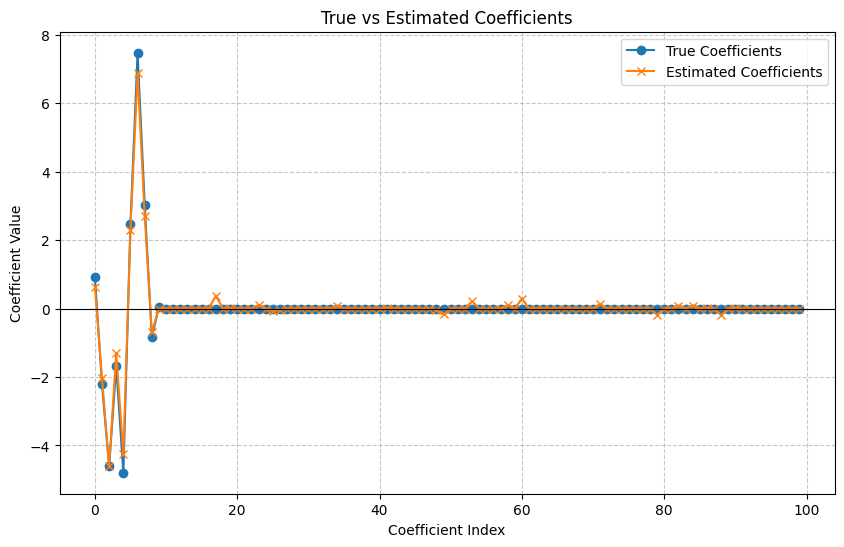

Time taken (seconds): 0.13505196571350098
Number of exact zeros in estimated coefficients: 70


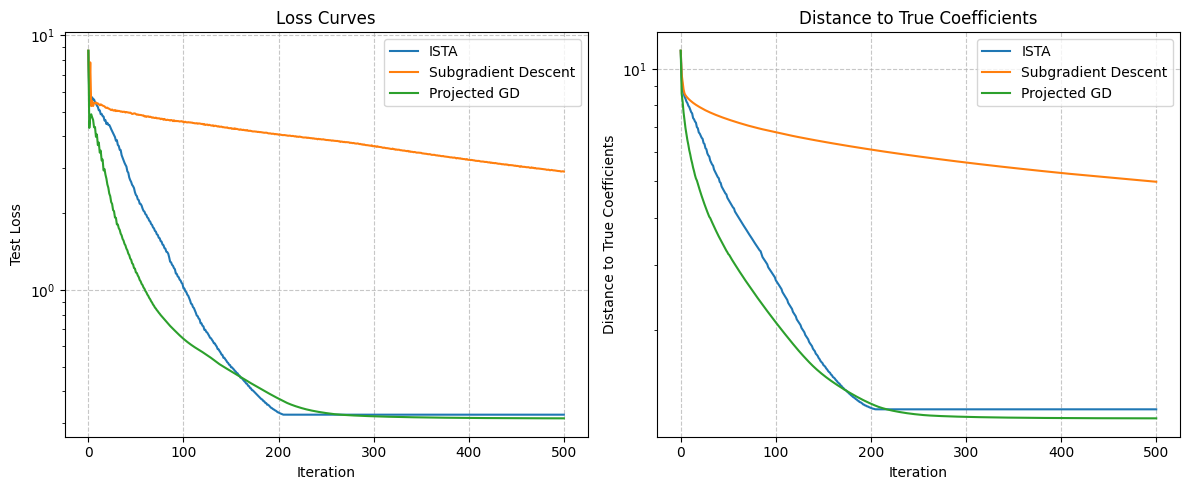

In [18]:
# run
ista_start_time = time.time()
w_est_ista, losses_ista, distance_from_coef_ista = ista(X_train, y_train, X_test, y_test, coef, lam=0.1, max_iter=500)
ista_time_taken = time.time() - ista_start_time
plot_coefficients(w_est_ista, coef)
print("Time taken (seconds):", ista_time_taken)
# number of exact zeros in the estimated coefficients
print("Number of exact zeros in estimated coefficients:", np.sum(w_est_ista == 0))
plot_loss_curves({'ISTA': losses_ista, "Subgradient Descent": losses, "Projected GD": losses_proj}, {'ISTA': distance_from_coef_ista, "Subgradient Descent": distance_to_true, "Projected GD": distance_from_coef_proj}, logy=True)

#### Coordinate descent leveraging close form solution and separability of proximal operator

This convex, separable loss can be optimized one parameter at a time:
$$
\beta_k^{t+1}
=
\arg\min_{\beta_k}
f(\beta_1^{t}, \beta_2^{t}, \dots, \beta_{k-1}^{t}, \beta_k, \dots, \beta_p^{t}).
$$

This has a closed form solution using an argument very close to the ISTA one using the Soft-tresholding. Consider the LASSO problem

$$
\min_{\beta}
\frac{1}{N}\sum_{i=1}^{N}
\left(
y_i - \sum_{k=1}^{p} x_{ik}\beta_k
\right)^2
+
\sum_{k=1}^{p} \lambda |\beta_k|,
$$
define:
$$
r_i^{(j)} \coloneqq
y_i - \sum_{k \ne j} x_{ik}\beta_k.
$$

Then the problem over each coordinate becomes:

$$
\min_{\beta_j}
\frac{1}{N}\sum_{i=1}^{N}
(r_i^{(j)} - x_{ij}\beta_j)^2
+
\lambda |\beta_j|
$$


Now, expanding and taking the derivative;

$$
\frac{1}{N}\sum_{i=1}^{N}
\left[
r_i^{(j)2}
-2x_{ij}r_i^{(j)}\beta_j
+
x_{ij}^2\beta_j^2
\right]
+
\lambda |\beta_j|,
$$

$$
-\frac{1}{N}\sum_{i=1}^{N} x_{ij} r_i^{(j)}
+
\frac{1}{N}\sum_{i=1}^{N} x_{ij}^2 \beta_j
+
\lambda \, \partial |\beta_j|
=0
$$

Let

$$
a = \frac{1}{N}\sum_{i=1}^{N} x_{ij}^2, \quad
b = \frac{1}{N}\sum_{i=1}^{N} x_{ij} r_i^{(j)}
$$

Then

$$
a \beta_j + \lambda \partial |\beta_j| = b.
$$

Case 1: $\beta_j > 0$ 

$$
\beta_j a + \lambda = b \Rightarrow \beta_j = \frac{b - \lambda}{a}
$$

If $b > 0 \Rightarrow \beta_j > 0$, otherwise we have a contradiction, since $a$ and $\lambda$ are positive scalars.

Case 2: $\beta_j < 0$

$$
\beta_j a - \lambda = b
\Rightarrow \beta_j = \frac{b + \lambda}{a}
$$

Case 3: $\beta_j = 0$


which leads to the **soft-thresholding update**:

$$
\hat{\beta}_j =
\frac{
S_\lambda
\left(
\frac{1}{N}\sum_{i=1}^{N} r_i^{(j)} x_{ij}
\right)
}{
\frac{1}{N}\sum_{i=1}^{N} x_{ij}^2
}
$$


Converged at iteration 240


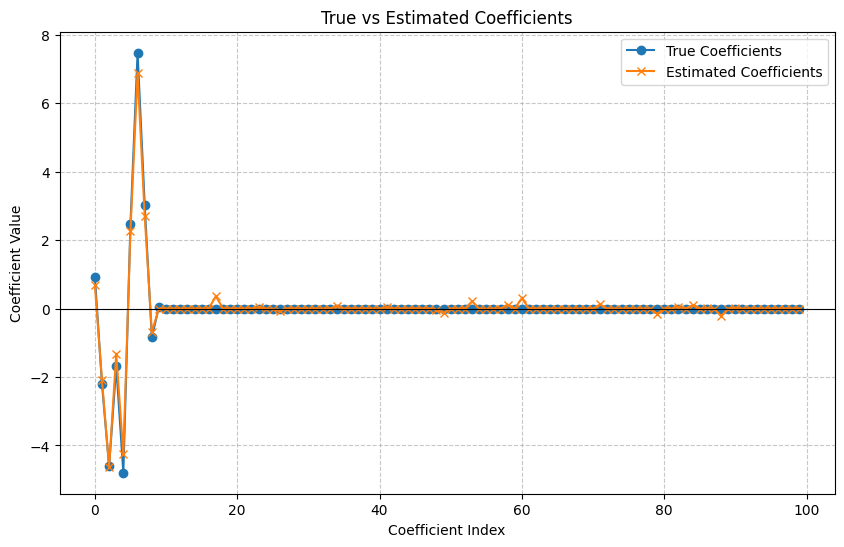

Time taken (seconds): 0.13904690742492676
Number of exact zeros in estimated coefficients: 70


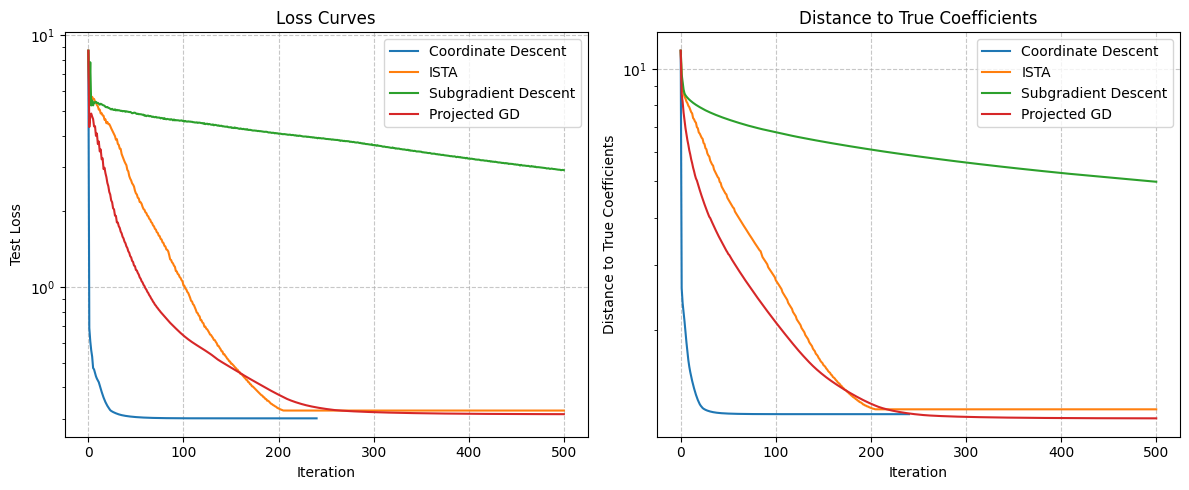

In [19]:
# implementation of CD for LASSO
def coordinate_descent(X, y, X_test, y_test, coef, lam, max, tol=1e-8):
    """
    Coordinate descent for LASSO: minimizes (1/(2n))||y - Xw||^2 + lam * ||w||_1

    Returns:
    - w: estimated coefficients
    - losses: list with objective value at initialization and after each update
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)

    def obj_test(w):
        res = y_test - X_test @ w
        return 0.5 * np.dot(res, res) / n_samples
    
    losses = []
    distance_from_coef = []
    losses.append(obj_test(w))
    distance_from_coef.append(np.linalg.norm(w - coef))

    a = np.sum(X**2, axis=0) / n_samples

    for i in range(max):
        w_old = w.copy()
        
        for j in range(n_features):
            # 1. Calculate partial residual correctly
            prediction = X @ w
            residual_j = y - prediction + w[j] * X[:, j] # literally we are adding back the contribution of the j-th feature to get the residual that excludes it
            # because is easier than indexing out the j-th feature from the prediction and recomputing it every time
            
            # 2. Calculate b
            b = (X[:, j].T @ residual_j) / n_samples
            
            # 3. Soft-thresholding: beta_j = S_lambda(b_j) / a_j
            w[j] = soft_thresholding(b, lam) / a[j]

        # Convergence Check: Compare the whole vector shift
        diff = np.linalg.norm(w - w_old, ord=np.inf)
        if diff < tol:
            print(f"Converged at iteration {i}")
            break
        
        losses.append(obj_test(w))
        distance_from_coef.append(np.linalg.norm(w - coef))

    return w, losses, distance_from_coef

# run coordinate descent
cd_start_time = time.time()
w_est_cd, losses_cd, distance_from_coef_cd = coordinate_descent(X_train, y_train, X_test, y_test, coef, lam=0.1, max=500)
cd_time_taken = time.time() - cd_start_time
plot_coefficients(w_est_cd, coef)
print("Time taken (seconds):", cd_time_taken)
# number of exact zeros in the estimated coefficients
print("Number of exact zeros in estimated coefficients:", np.sum(w_est_cd == 0))
plot_loss_curves({'Coordinate Descent': losses_cd, 'ISTA': losses_ista, "Subgradient Descent": losses, "Projected GD": losses_proj}, {'Coordinate Descent': distance_from_coef_cd, 'ISTA': distance_from_coef_ista, "Subgradient Descent": distance_to_true, "Projected GD": distance_from_coef_proj}, logy=True)

It is important to mention that there is also accelerated versions of ISTA, FISTA that have a convergence rate of $\mathcal{O}(\frac{1}{k^2})$. We will get into this, particularly to compare FISTA vs Coordinate descent for millions of dimensions and availability of GPU!

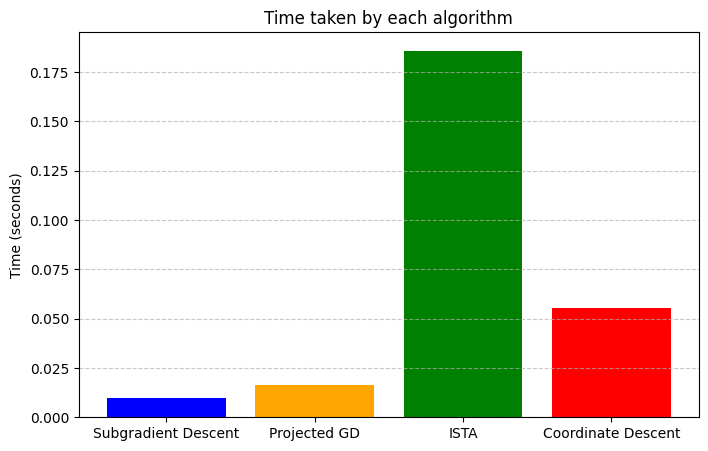

In [20]:
# Plot the barplot for the times
algorithms = ['Subgradient Descent', 'Projected GD', 'ISTA', 'Coordinate Descent']
times = [time_taken, time_taken_proj, ista_time_taken, cd_time_taken]
plt.figure(figsize=(8, 5))
bars = plt.bar(algorithms, times, color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Time (seconds)')
plt.title('Time taken by each algorithm')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()